# MXene Voltage — RSHAP Instance Analysis

Dataset: MXene materials, Mendeleev elemental features.  
Reference: [10.1021/ja508154e](https://doi.org/10.1021/ja508154e)

This notebook demonstrates the full RSHAP workflow on a real materials dataset:

1. **Regression** — predict Voltage; run RSHAP to identify influential and sensitive training instances
2. **Classification** — binarise Voltage (High / Low); run RSHAP to decompose misclassification residuals; colour CC plots by TP / TN / FP / FN
3. **SHAP** — feature-level attribution for comparison

> Liu, T. & Barnard, A. S. (2023). *Shapley Based Residual Decomposition for Instance Analysis.*  
> ICML 2023, PMLR 202, pp. 21375–21387.  
> <https://proceedings.mlr.press/v202/liu23b.html>

## Imports

In [3]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    cross_val_predict, learning_curve, RandomizedSearchCV,
)
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.metrics import (
    make_scorer, r2_score,
    mean_squared_error, mean_absolute_error,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.exceptions import ConvergenceWarning

import xgboost as xgb
import shap

from RSHAP import ResidualDecompositionSymmetric, draw_heatmap

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [4]:
# ── RSHAP global settings ────────────────────────────────────────────────────
# ITERATIONS : number of symmetric permutation pairs to average over.
#              Higher = lower variance phi matrix; longer runtime.
# N_JOBS     : set to 1 on Windows to avoid paging-file errors ([WinError 1455]);
#              set to -1 to use all CPU cores.
ITERATIONS = 100
N_JOBS     = 1

## Load the Data

In [6]:
df = pd.read_csv('mxene_mendeleev.csv')
df = df[(np.abs(zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)].reset_index(drop=True)

dataname   = 'Voltage'
drop_cols  = ['ID', 'Formula', 'Voltage', 'Capacity', 'Charge', 'In-plane_lattice', 'Intercalated_lattice']
X_features = df.drop(drop_cols, axis=1)
y_label    = df[dataname].values

print(f"Dataset shape after z-score filter: {X_features.shape}")
print(f"Voltage range: {y_label.min():.3f} – {y_label.max():.3f} V")

Dataset shape after z-score filter: (358, 22)
Voltage range: -1.680 – 1.890 V


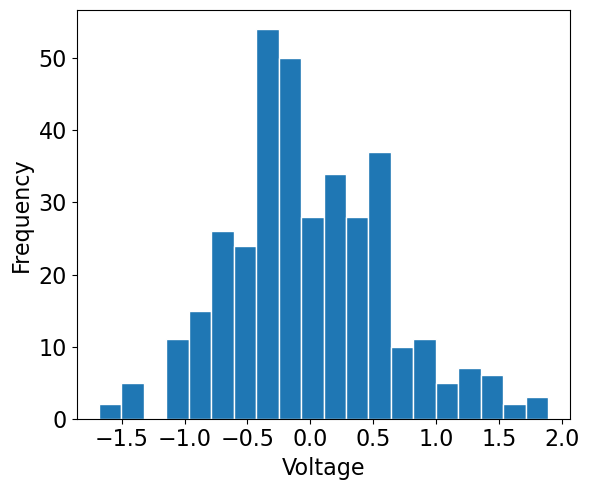

In [7]:
os.makedirs('FIGURES', exist_ok=True)

plt.figure(figsize=(6, 5))
plt.hist(y_label, bins=20, edgecolor='white')
plt.xlabel(dataname, fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ── Separate numeric features from categorical group labels ──────────────────
X_numeric = X_features.drop(['M', 'X', 'T', 'Z'], axis=1)

# ── Train / test split (75 / 25) ─────────────────────────────────────────────
(
    X_tr_raw, X_ts_raw,
    y_train,  y_test,
    idx_train, idx_test,
) = train_test_split(
    X_numeric, y_label, np.arange(len(y_label)),
    test_size=0.25, random_state=42,
)

# Group labels for the training instances — used for CC plots and heatmaps
m_labels = X_features.iloc[idx_train]['M'].astype(str).reset_index(drop=True)
x_labels = X_features.iloc[idx_train]['X'].astype(str).reset_index(drop=True)
t_labels = X_features.iloc[idx_train]['T'].astype(str).reset_index(drop=True)
z_labels = X_features.iloc[idx_train]['Z'].astype(str).reset_index(drop=True)

# ── Preprocessing: MinMaxScaler → PowerTransformer ───────────────────────────
scaler        = MinMaxScaler()
X_tr_scaled   = scaler.fit_transform(X_tr_raw)
X_ts_scaled   = scaler.transform(X_ts_raw)

power_trans   = PowerTransformer()
X_train_trans = power_trans.fit_transform(X_tr_scaled)
X_test_trans  = power_trans.transform(X_ts_scaled)

# DataFrame form keeps column names for SHAP later
X_train = pd.DataFrame(X_train_trans, columns=X_tr_raw.columns)
X_test  = pd.DataFrame(X_test_trans,  columns=X_ts_raw.columns)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (268, 18)   Test: (90, 18)


## Part 1 — Regression: Predicting Voltage

In [10]:
# ── XGBoost hyperparameters ───────────────────────────────────────────────────
# Obtained from RandomizedSearchCV (commented out below to avoid long runtime).
# These SAME params are passed to both the prediction model and RSHAP — see Part 2.
xgb_params = {
    'reg_lambda':    0.122,
    'reg_alpha':     0.2964,
    'n_estimators':  193,
    'max_depth':     2,
    'learning_rate': 0.483,
    'gamma':         6.518e-05,
}

# ── Uncomment to re-run the hyperparameter search ────────────────────────────
# param_dist = dict(
#     learning_rate = np.logspace(-3, 0, 20),
#     n_estimators  = np.arange(50, 201, 10),
#     max_depth     = np.arange(2, 11),
#     gamma         = np.logspace(-5, np.log10(5), 8),
#     reg_alpha     = np.random.uniform(0, 1, 10),
#     reg_lambda    = np.random.uniform(0, 1, 10),
# )
# search = RandomizedSearchCV(
#     xgb.XGBRegressor(n_jobs=-1, random_state=42),
#     param_distributions=param_dist, n_iter=500,
#     cv=5, scoring='r2', random_state=42,
# )
# search.fit(X_train_trans, y_train)
# xgb_params = search.best_params_
# print("Best params:", xgb_params, "  Best CV R²:", search.best_score_)

In [11]:
# ── Step 1 — Train YOUR prediction model ─────────────────────────────────────
# This is the model used for making predictions and evaluating performance.
# RSHAP (Part 2) is a separate analysis that uses the same xgb_params to build
# its own fresh model instances internally — it does NOT receive this fitted model.
model = xgb.XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)
model.fit(X_train_trans, y_train)

cv    = KFold(n_splits=10, shuffle=True, random_state=42)
cv_r2 = cross_val_score(model, X_train_trans, y_train, cv=cv, scoring='r2')
y_pred = model.predict(X_test_trans)

print(f"Training R²  : {model.score(X_train_trans, y_train):.3f}")
print(f"CV R²        : {cv_r2.mean():.3f} ± {2*cv_r2.std():.3f}  (10-fold, 2σ)")
print(f"\nTest R²    : {r2_score(y_test, y_pred):.3f}")
print(f"Test MAE   : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Test RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Training R²  : 0.803
CV R²        : 0.748 ± 0.198  (10-fold, 2σ)

Test R²    : 0.811
Test MAE   : 0.2170
Test RMSE  : 0.2729


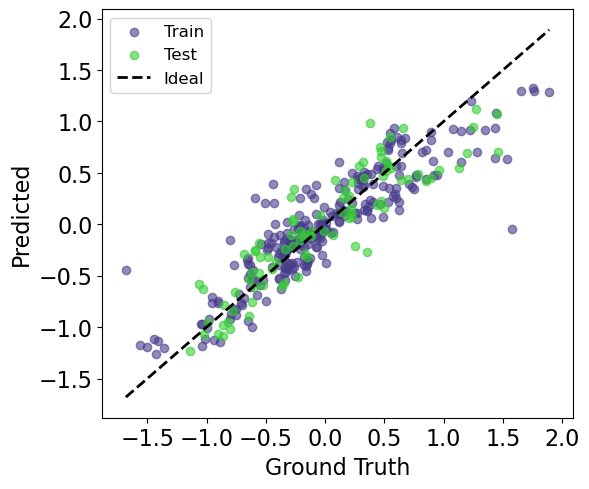

In [12]:
# ── Parity plot ───────────────────────────────────────────────────────────────
y_train_pred = model.predict(X_train_trans)
all_vals     = np.concatenate([y_train, y_test, y_train_pred, y_pred])
lo, hi, buf  = all_vals.min(), all_vals.max(), 0.2

plt.figure(figsize=(6, 5))
plt.scatter(y_train, y_train_pred, color='darkslateblue', marker='o', alpha=0.6, label='Train')
plt.scatter(y_test,  y_pred,       color='limegreen',     marker='o', alpha=0.6, label='Test')
plt.plot([lo, hi], [lo, hi], 'k--', linewidth=2, label='Ideal')
plt.xlabel('Ground Truth', fontsize=16)
plt.ylabel('Predicted',    fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.xlim(lo - buf, hi + buf); plt.ylim(lo - buf, hi + buf)
plt.legend(loc='upper left', facecolor='none', fontsize=12)
plt.tight_layout()
plt.show()

## Part 2 — RSHAP Regression Analysis

**Workflow note — RSHAP vs your prediction model.**

The `model` trained above and RSHAP are completely independent objects.
RSHAP does **not** receive the fitted `model` — it receives the model *class* and the same
`xgb_params` dictionary, and uses them to build hundreds of fresh model instances internally,
each trained on a different random subset of the data.

Passing the **same** `xgb_params` ensures that the model RSHAP trains internally behaves
identically to the one used for prediction.  If you use different hyperparameters RSHAP will
describe a different model's residuals — results will not be interpretable as an analysis of
the model you actually deployed.

The phi matrix has shape `(N_train, N_train)`.  Each entry `phi[k, j]` is the expected change
in instance j's prediction residual when instance k is added to the training coalition.

- **Composition score** (x-axis of CC plot): column sum — how much an instance's own residual
  fluctuates as training data are added around it
- **Contribution score** (y-axis of CC plot): row sum — how much an instance shifts the
  residuals of all other instances when it enters the training coalition

In [14]:
# ── Step 2 — Run RSHAP with the SAME class and params as the prediction model ─
rshap = ResidualDecompositionSymmetric()
rshap.fit(
    X_train_trans, y_train,
    model_class=xgb.XGBRegressor,   # same class as 'model' above
    model_params=xgb_params,         # same params as 'model' above
    iterations=ITERATIONS,
    regression=True,
    n_jobs=N_JOBS,
)
print("RSHAP regression fit complete.")
print(f"phi matrix shape: {rshap.get_composition().shape}")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [10:13<00:00,  6.13s/it]

RSHAP regression fit complete.
phi matrix shape: (268, 268)


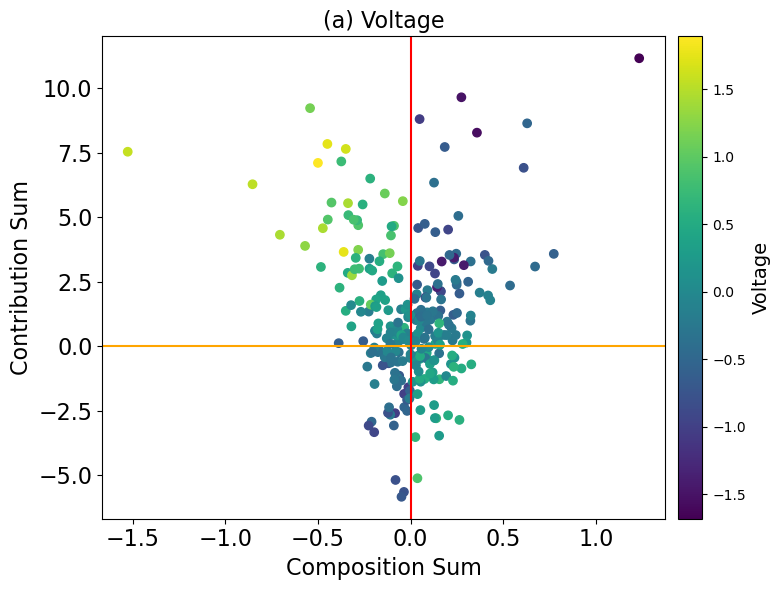

In [15]:
# ── CC plot — continuous coloring by Voltage ──────────────────────────────────
# Points colored by the training target give a first read of whether
# high/low voltage instances occupy distinct regions of RSHAP space.
plt.figure(figsize=(8, 6))
plt.title(f'(a) {dataname}', fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
sc = rshap.cc_plot(coloring=y_train, fontsizes=16)
cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label(f'{dataname}', fontsize=14)
plt.tight_layout()
plt.show()

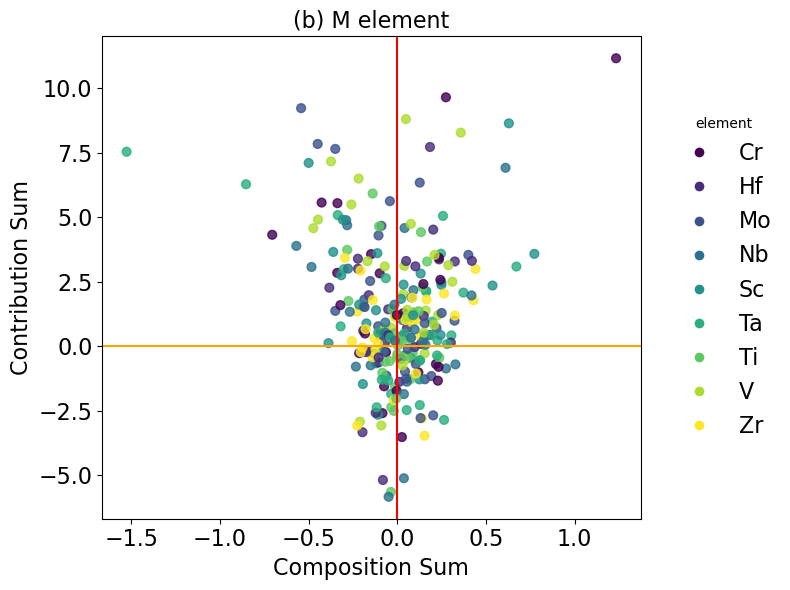

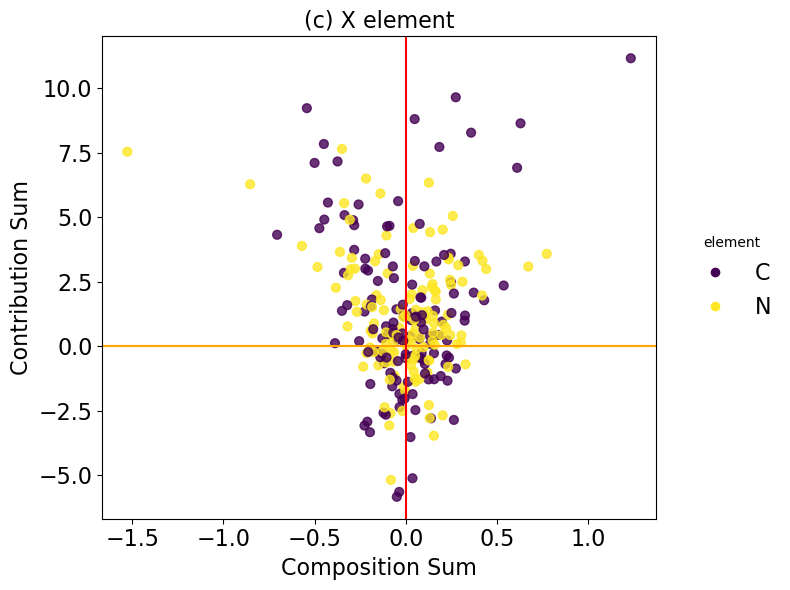

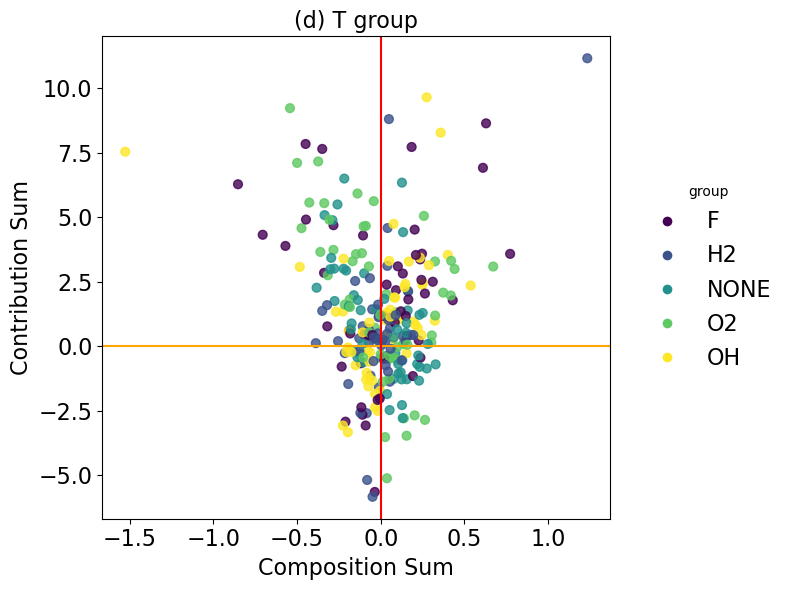

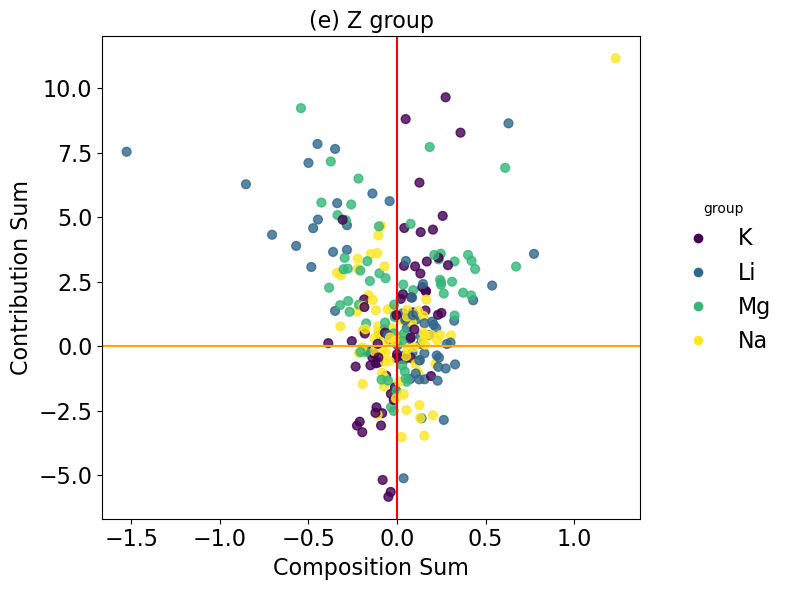

In [16]:
# ── CC plots — categorical coloring by chemical group labels ──────────────────
# Each group gets its own color so you can see whether chemical families
# cluster together in RSHAP space.
for labels, tag, title in [
    (m_labels, 'CCm', '(b) M element'),
    (x_labels, 'CCx', '(c) X element'),
    (t_labels, 'CCt', '(d) T group'),
    (z_labels, 'CCz', '(e) Z group'),
]:
    plt.figure(figsize=(8, 6))
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=16); plt.yticks(fontsize=16)
    rshap.cc_plot(
        coloring=labels,
        fontsizes=16,
        legend_label=title.split()[-1],
        drawparams={'marker': 'o', 's': 40, 'alpha': 0.8},
    )
    plt.tight_layout()
    plt.show()

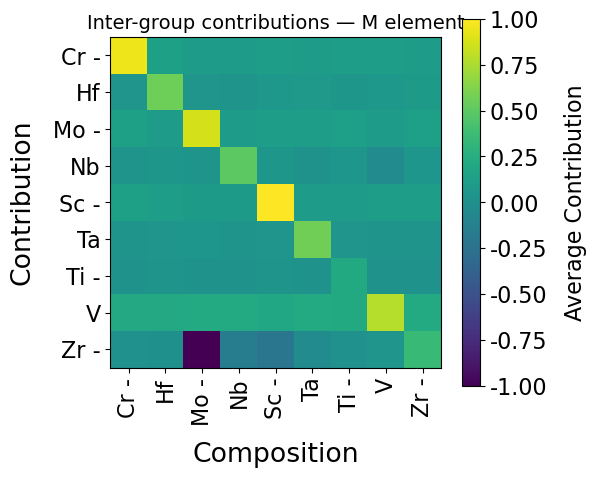

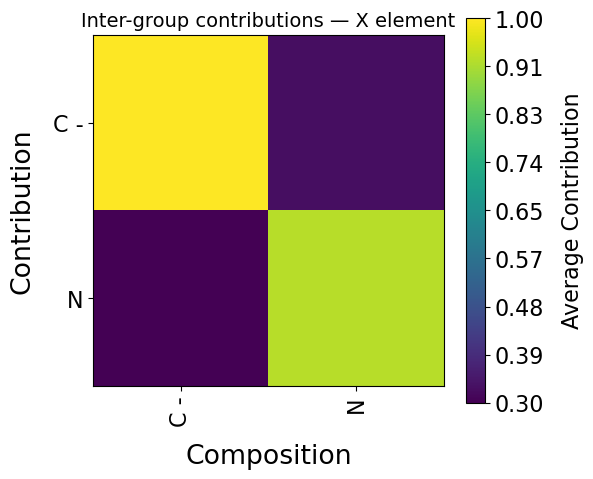

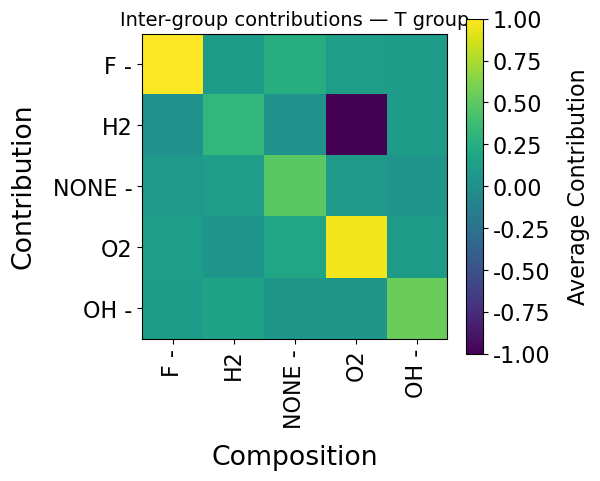

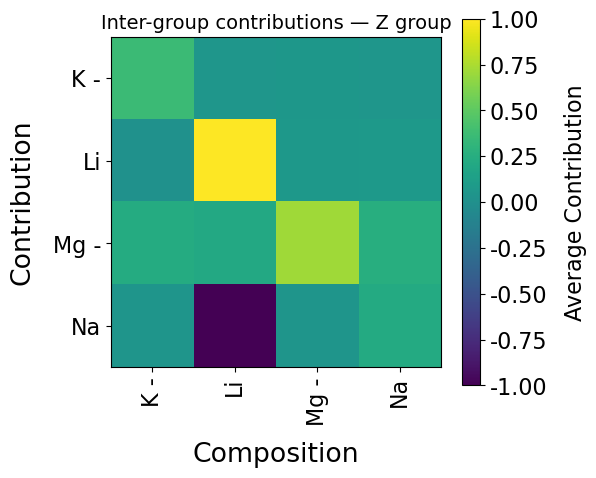

In [17]:
# ── Heatmaps — inter-group contributions by chemical group ────────────────────
# Each cell shows the mean signed contribution from all instances in one group
# to all instances in another group.
# Rows = givers (Contribution axis), Columns = receivers (Composition axis).
# Negative diagonal = within-group instances help each other (expected pattern).
for labels, tag, title in [
    (m_labels, 'HMm', 'M element'),
    (x_labels, 'HMx', 'X element'),
    (t_labels, 'HMt', 'T group'),
    (z_labels, 'HMz', 'Z group'),
]:
    fig, ax = draw_heatmap(rshap, labels, fontsizes=16)
    ax.set_title(f'Inter-group contributions — {title}', fontsize=14)
    plt.show()

## Part 3 — Classification: High vs Low Voltage

We binarise the Voltage target at its median to create a balanced two-class problem.
A separate XGBoost classifier is trained on the same pre-processed features.

RSHAP is then run with `regression=False` so the phi matrix decomposes
*misclassification events* — each residual is 1 if the prediction is wrong, 0 if correct —
rather than continuous error magnitudes.  This lets us ask: *which training instances
cause others to be misclassified?*

In [19]:
# ── Binarise Voltage at the training-set median ───────────────────────────────
voltage_median = np.median(y_train)
y_train_binary = (y_train > voltage_median).astype(int)   # 1 = High, 0 = Low
y_test_binary  = (y_test  > voltage_median).astype(int)

n_high = int(y_train_binary.sum())
n_low  = len(y_train_binary) - n_high
print(f"Median voltage (train) : {voltage_median:.3f} V")
print(f"Class balance (train)  : High={n_high}, Low={n_low}")

# ── Classifier params — same tree hyperparameters as the regressor ────────────
# XGBClassifier accepts all the same params as XGBRegressor.
clf_params = dict(xgb_params)

# ── Step 3 — Train YOUR classification model ──────────────────────────────────
clf = xgb.XGBClassifier(**clf_params, random_state=42, n_jobs=-1)
clf.fit(X_train_trans, y_train_binary)

cv_acc            = cross_val_score(clf, X_train_trans, y_train_binary, cv=5, scoring='accuracy')
y_test_pred_bin   = clf.predict(X_test_trans)

print(f"\nCV accuracy (5-fold)   : {cv_acc.mean():.3f} ± {2*cv_acc.std():.3f}  (2σ)")
print("\nTest set classification report:")
print(classification_report(y_test_binary, y_test_pred_bin, target_names=['Low', 'High']))

Median voltage (train) : -0.100 V
Class balance (train)  : High=133, Low=135

CV accuracy (5-fold)   : 0.877 ± 0.029  (2σ)

Test set classification report:
              precision    recall  f1-score   support

         Low       0.98      0.93      0.96        46
        High       0.93      0.98      0.96        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



## Part 4 — RSHAP Classification Analysis

RSHAP with `regression=False` decomposes *misclassification events* rather than
continuous residuals.  The phi matrix entry `phi[k, j]` captures the expected change
in whether instance j is correctly classified when instance k joins the training coalition.

The CC plots below reveal which training instances are structurally hard to learn from
(high composition score) and which instances cause trouble for others when included
(high positive contribution score).  Coloring by prediction outcome (TP / TN / FP / FN)
from 5-fold cross-validation pinpoints exactly which instances the model fails on.

In [21]:
# ── Step 4 — Run RSHAP classification with the SAME class and params as clf ──
rshap_clf = ResidualDecompositionSymmetric()
rshap_clf.fit(
    X_train_trans, y_train_binary,
    model_class=xgb.XGBClassifier,   # same class as clf above
    model_params=clf_params,          # same params as clf above
    iterations=ITERATIONS,
    regression=False,                 # classification: residual = 1 if wrong, 0 if correct
    n_jobs=N_JOBS,
)
print("RSHAP classification fit complete.")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [10:54<00:00,  6.54s/it]

RSHAP classification fit complete.


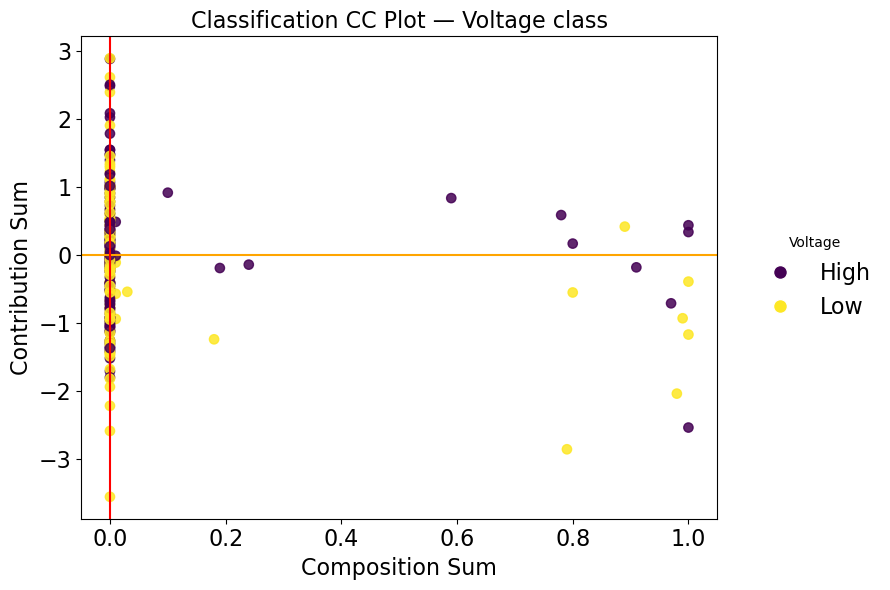

In [22]:
# ── CC plot — colored by voltage class (High / Low) ──────────────────────────
voltage_class = np.where(y_train_binary == 1, 'High', 'Low')

plt.figure(figsize=(9, 6))
plt.title('Classification CC Plot — Voltage class', fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
rshap_clf.cc_plot(
    coloring=voltage_class,
    fontsizes=16,
    legend_label='Voltage',
    drawparams={'marker': 'o', 's': 45, 'alpha': 0.85},
)
plt.tight_layout()
plt.show()

5-fold CV outcome counts on training set: {'TP': 119, 'TN': 116, 'FP': 19, 'FN': 14}


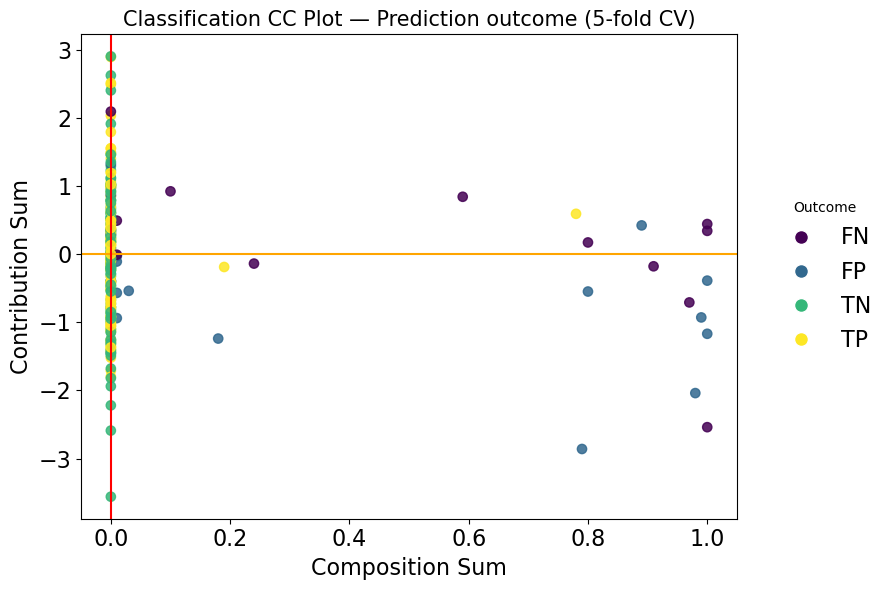

In [23]:
# ── 5-fold CV predictions → TP / TN / FP / FN labels ────────────────────────
# cross_val_predict gives out-of-fold predictions: realistic FP/FN that reflect
# genuine generalisation errors, not training-set overfitting.
clf_cv    = xgb.XGBClassifier(**clf_params, random_state=42, n_jobs=-1)
y_cv_pred = cross_val_predict(clf_cv, X_train_trans, y_train_binary, cv=5)

def outcome_label(true, pred):
    if true == 1 and pred == 1: return 'TP'
    if true == 0 and pred == 0: return 'TN'
    if true == 0 and pred == 1: return 'FP'
    return 'FN'

outcome_labels = np.array([outcome_label(t, p) for t, p in zip(y_train_binary, y_cv_pred)])
counts = {k: int((outcome_labels == k).sum()) for k in ['TP', 'TN', 'FP', 'FN']}
print("5-fold CV outcome counts on training set:", counts)

# ── CC plot — colored by TP / TN / FP / FN ───────────────────────────────────
# Instances displaced from the main cloud are those the model finds hardest:
# high positive composition → residual persists regardless of training context
# negative contribution    → adding this instance degrades others' predictions
plt.figure(figsize=(9, 6))
plt.title('Classification CC Plot — Prediction outcome (5-fold CV)', fontsize=15)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
rshap_clf.cc_plot(
    coloring=outcome_labels,
    fontsizes=16,
    legend_label='Outcome',
    drawparams={'marker': 'o', 's': 45, 'alpha': 0.85},
)
plt.tight_layout()
plt.show()

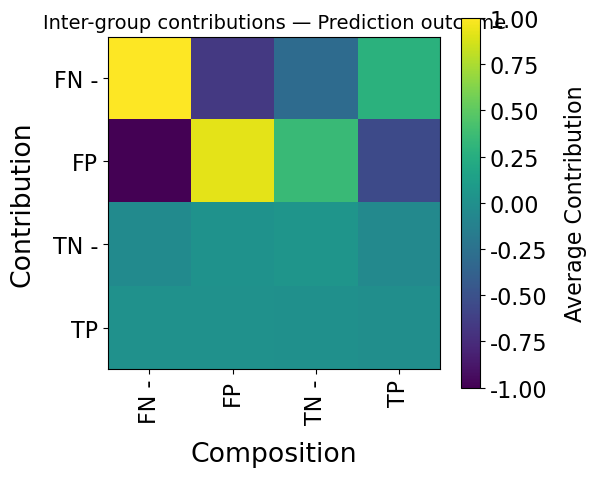

In [24]:
# ── Heatmap — inter-group contributions by prediction outcome ─────────────────
# Which outcome groups disproportionately affect the misclassification of others?
fig, ax = draw_heatmap(rshap_clf, outcome_labels, fontsizes=16)
ax.set_title('Inter-group contributions — Prediction outcome', fontsize=14)
plt.show()